## Import Library

In [1]:
import os
import random
import pathlib
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

import warnings
warnings.filterwarnings('ignore')

## Konfigurasi Path & Parameter Audio

In [2]:
ROOT_DIR = pathlib.Path(r"c:\S2-Ilmu Komputer 24\Project\Kambing")
DATASET_DIR = ROOT_DIR / "Dataset"
RESULTS_DIR = ROOT_DIR / "Results"
SPEC_IMG_DIR = RESULTS_DIR / "Spectrogram_Images"

# Buat folder jika belum ada
SPEC_IMG_DIR.mkdir(parents=True, exist_ok=True)

SR = 16000
DURATION = 2.0
N_MFCC = 40
N_MELS = 128

CLASSES = ["lapar", "normal", "stress"]

## Ekstraksi Fitur

Di sini kita akan melakukan iterasi pada seluruh dataset:
- **Spectrogram**: Akan kita *flatten* (ratakan) menjadi array 1D agar bisa masuk ke model DNN. Kita juga akan men-save 4 gambar Spectrogram secara random dari masing-masing label.
- **MFCC-40**: Kita hitung nilai *Mean* dan *Standard Deviation* di sumbu waktu, menghasilkan 80 fitur. Fitur ini akan disimpan ke dalam bentuk **CSV**.

In [3]:
spectrogram_features = []
mfcc_features_list = []
labels = []
file_names = []

# Untuk menyimpan batas random plot gambar
images_saved_per_class = {c: 0 for c in CLASSES}
MAX_IMG_PER_CLASS = 4

for cls in CLASSES:
    cls_dir = DATASET_DIR / cls
    if not cls_dir.exists():
        continue
        
    wav_files = list(cls_dir.glob("*.wav"))
    # Acak file agar gambar yang di-save juga random setiap run
    random.shuffle(wav_files)
    
    for wav_path in tqdm(wav_files, desc=f"Ekstraksi {cls}"):
        y, sr = librosa.load(str(wav_path), sr=SR, duration=DURATION)
        
        # Pastikan panjang audio konsisten (padding jika kurang)
        target_len = int(SR * DURATION)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        # --------------------------------------------------------
        # 1. MEL-SPECTROGRAM
        # --------------------------------------------------------
        melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        melspec_db = librosa.power_to_db(melspec, ref=np.max)
        
        # Simpan gambar jika kuota belum terpenuhi
        if images_saved_per_class[cls] < MAX_IMG_PER_CLASS:
            plt.figure(figsize=(6, 4))
            librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f'Mel-Spectrogram - {cls.upper()}')
            plt.tight_layout()
            
            img_name = SPEC_IMG_DIR / f"{cls}_sample_{images_saved_per_class[cls]+1}.png"
            plt.savefig(str(img_name))
            plt.close()
            images_saved_per_class[cls] += 1

        # Flatten spectrogram untuk DNN (128 mels * frame_count)
        spectrogram_features.append(melspec_db.flatten())
        
        # --------------------------------------------------------
        # 2. MFCC-40
        # --------------------------------------------------------
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        
        mfcc_combined = np.hstack([mfcc_mean, mfcc_std])
        mfcc_features_list.append(mfcc_combined)
        
        labels.append(cls)
        file_names.append(wav_path.name)

X_spec = np.array(spectrogram_features)
X_mfcc = np.array(mfcc_features_list)
y_labels = np.array(labels)

print(f"Dimensi Spectrogram (Flatten) : {X_spec.shape}")
print(f"Dimensi MFCC-40 (Mean+Std)    : {X_mfcc.shape}")

Ekstraksi stress: 100%|██████████| 97/97 [00:02<00:00, 43.35it/s]

Dimensi Spectrogram (Flatten) : (717, 8064)
Dimensi MFCC-40 (Mean+Std)    : (717, 80)


## Hasil MFCC ke CSV

In [4]:
# Buat nama kolom untuk CSV
columns = ['file_name', 'label']
columns += [f'mfcc_mean_{i+1}' for i in range(N_MFCC)]
columns += [f'mfcc_std_{i+1}' for i in range(N_MFCC)]

# Susun data frame
df_mfcc = pd.DataFrame(X_mfcc)
df_mfcc.insert(0, 'label', y_labels)
df_mfcc.insert(0, 'file_name', file_names)
df_mfcc.columns = columns

# Simpan ke CSV
csv_path = RESULTS_DIR / "mfcc40_features.csv"
df_mfcc.to_csv(csv_path, index=False)

display(df_mfcc.head(5))

,file_name,label,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,...,mfcc_std_31,mfcc_std_32,mfcc_std_33,mfcc_std_34,mfcc_std_35,mfcc_std_36,mfcc_std_37,mfcc_std_38,mfcc_std_39,mfcc_std_40
0,lapar 199.wav,lapar,-258.387024,109.123222,-29.867861,37.207790,-15.974255,7.862679,6.209421,6.337107,...,3.873560,3.719980,4.786060,3.441787,3.104949,4.371497,3.192113,4.437247,3.100778,3.712572
1,lapar 110.wav,lapar,-208.510498,103.077347,-34.671028,60.965092,-17.008600,12.864764,3.684496,11.207492,...,5.922183,5.838924,3.775239,3.188353,6.169868,4.092530,4.191126,4.443765,3.836892,3.128109
2,lapar 147.wav,lapar,-137.404877,101.823013,-51.203880,36.637413,-34.627384,2.004730,-3.120618,-3.411362,...,5.276212,6.681398,8.874447,7.387929,4.316326,6.480198,6.705929,3.297300,4.343497,3.305789
3,lapar 145.wav,lapar,-199.851532,102.782791,-28.859598,43.680504,-16.490932,2.379238,7.097131,-6.286954,...,6.202840,6.031779,6.466882,6.704069,6.287124,5.320513,4.972522,4.074007,5.367402,6.750795
4,lapar 60.wav,lapar,-193.275375,53.810928,-23.563610,31.336447,-13.104862,2.214806,-6.845194,0.942314,...,4.323417,4.398624,4.070159,2.912506,4.009373,3.777047,2.883684,3.583955,3.820715,3.969851


## Persiapan Data untuk Model DNN

In [ ]:
# Encode labels (lapar=0, normal=1, stress=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

# Train-test split (Spectrogram)
X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X_spec, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train-test split (MFCC)
X_train_mfcc, X_test_mfcc, y_train_mfcc, y_test_mfcc = train_test_split(
    X_mfcc, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalisasi menggunakan StandardScaler
scaler_spec = StandardScaler()
X_train_spec = scaler_spec.fit_transform(X_train_spec)
X_test_spec = scaler_spec.transform(X_test_spec)

scaler_mfcc = StandardScaler()
X_train_mfcc = scaler_mfcc.fit_transform(X_train_mfcc)
X_test_mfcc = scaler_mfcc.transform(X_test_mfcc)

Data siap untuk ditraining!


## Membuat & Melatih Model DNN
Kita akan menggunakan arsitektur DNN yang sama untuk kedua fitur agar perbandingannya adil.

In [6]:
def create_dnn_model(input_dim, num_classes=3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

EPOCHS = 30
BATCH_SIZE = 32

### A. Training Model Spectrogram
*(Karena dimensi fiturnya sangat besar, model DNN biasanya kesulitan menemukan pola (overfitting) dan hasilnya kurang baik tanpa Convolutional Layer)*

In [ ]:
model_spec = create_dnn_model(input_dim=X_train_spec.shape[1])

history_spec = model_spec.fit(
    X_train_spec, y_train_spec,
    validation_data=(X_test_spec, y_test_spec),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

_, acc_spec = model_spec.evaluate(X_test_spec, y_test_spec, verbose=0)
print(f"Akurasi Test Spectrogram: {acc_spec * 100:.2f}%")

⏳ Melatih DNN dengan fitur Spectrogram (Flatten)...
Akurasi Test Spectrogram: 95.83%


### B. Training Model MFCC-40
*(MFCC mengekstraksi inti suara dalam dimensi yang sangat ringkas (80 fitur). Ini membuat DNN jauh lebih mudah mengklasifikasikan data!)*

In [ ]:
model_mfcc = create_dnn_model(input_dim=X_train_mfcc.shape[1])

history_mfcc = model_mfcc.fit(
    X_train_mfcc, y_train_mfcc,
    validation_data=(X_test_mfcc, y_test_mfcc),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

_, acc_mfcc = model_mfcc.evaluate(X_test_mfcc, y_test_mfcc, verbose=0)
print(f"Akurasi Test MFCC-40: {acc_mfcc * 100:.2f}%")

⏳ Melatih DNN dengan fitur MFCC-40 (Mean+Std)...
Akurasi Test MFCC-40: 98.61%


## Evaluasi Model

In [9]:
# Evaluasi Spectrogram
y_pred_spec = np.argmax(model_spec.predict(X_test_spec, verbose=0), axis=1)
print("========== EVALUASI SPECTROGRAM ==========")
print(classification_report(y_test_spec, y_pred_spec, target_names=le.classes_))

# Evaluasi MFCC-40
y_pred_mfcc = np.argmax(model_mfcc.predict(X_test_mfcc, verbose=0), axis=1)
print("\n========== EVALUASI MFCC-40 ==========")
print(classification_report(y_test_mfcc, y_pred_mfcc, target_names=le.classes_))

========== EVALUASI SPECTROGRAM ==========
              precision    recall  f1-score   support

       lapar       0.96      0.92      0.94        50
      normal       0.95      0.97      0.96        75
      stress       1.00      1.00      1.00        19

    accuracy                           0.96       144
   macro avg       0.97      0.96      0.97       144
weighted avg       0.96      0.96      0.96       144


========== EVALUASI MFCC-40 ==========
              precision    recall  f1-score   support

       lapar       1.00      0.96      0.98        50
      normal       0.99      1.00      0.99        75
      stress       0.95      1.00      0.97        19

    accuracy                           0.99       144
   macro avg       0.98      0.99      0.98       144
weighted avg       0.99      0.99      0.99       144



## Grafik Perbandingan Hasil Akhir

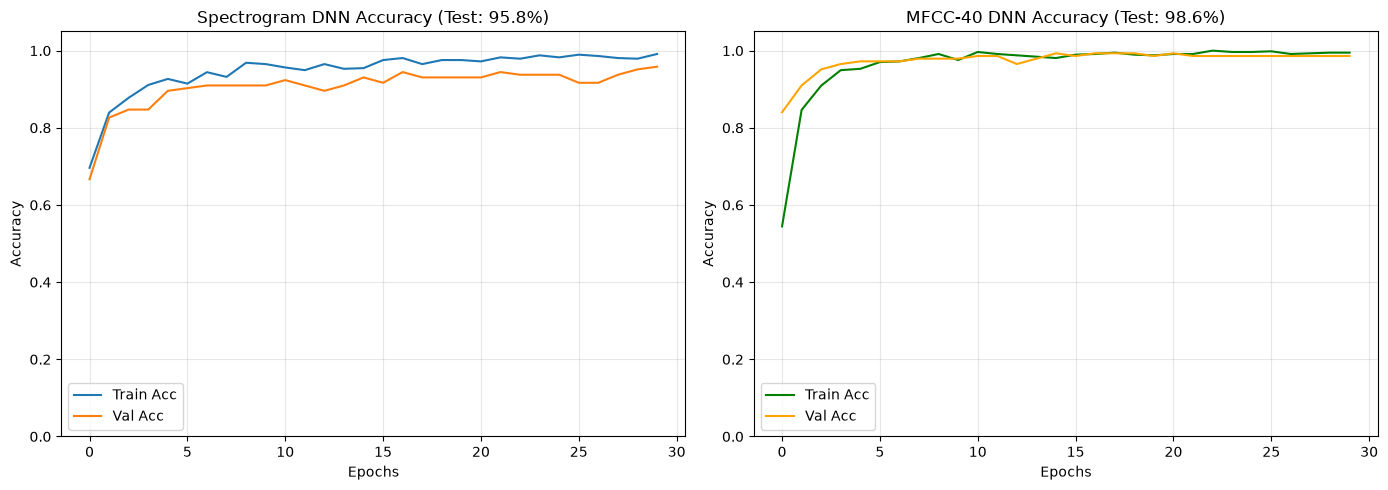


✅ KESIMPULAN:
MFCC-40 jauh lebih unggul saat menggunakan model Dense Neural Network (DNN).
Spectrogram (jika hanya di-flatten) menyimpan terlalu banyak noise dan membutuhkan dimensi sangat besar, sehingga model kesulitan mempelajarinya (kecuali jika kita menggunakan CNN).


In [ ]:
plt.figure(figsize=(14, 5))

# Akurasi Spectrogram
plt.subplot(1, 2, 1)
plt.plot(history_spec.history['accuracy'], label='Train Acc')
plt.plot(history_spec.history['val_accuracy'], label='Val Acc')
plt.title(f"Spectrogram DNN Accuracy (Test: {acc_spec*100:.1f}%)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

# Akurasi MFCC-40
plt.subplot(1, 2, 2)
plt.plot(history_mfcc.history['accuracy'], label='Train Acc', color='green')
plt.plot(history_mfcc.history['val_accuracy'], label='Val Acc', color='orange')
plt.title(f"MFCC-40 DNN Accuracy (Test: {acc_mfcc*100:.1f}%)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ KESIMPULAN:")
print("MFCC-40 jauh lebih unggul saat menggunakan model Dense Neural Network (DNN).")
print("Spectrogram (jika hanya di-flatten) menyimpan terlalu banyak noise dan membutuhkan dimensi sangat besar, sehingga model kesulitan mempelajarinya (kecuali jika kita menggunakan CNN).")